# CIC-IDS-2017 model screening investigation

This notebook is a fixed, read-only investigation of the completed baseline, tree, and neural screening rounds. It presents the evidence in decision order and does not expose report parameters, train models, or evaluate the protected test partition.

Use MLflow or `ids-show-results` when a custom round filter or the complete run-level leaderboard is needed.

## 1. Load the fixed investigation scope

All three screening rounds are queried together. The reporting layer selects one shared dataset and split contract, then retains the latest successful run for each configuration.

In [1]:
import warnings
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from ids_ml.reporting import (
    best_per_family,
    build_screening_report,
    download_csv_artifact,
)

MODEL_NAMES = {
    "XGBClassifier": "XGBoost",
    "LGBMClassifier": "LightGBM",
    "HistGradientBoostingClassifier": "Histogram Gradient Boosting",
    "RandomForestClassifier": "Random Forest",
    "ExtraTreesClassifier": "Extra Trees",
    "DecisionTreeClassifier": "Decision Tree",
    "SGDClassifier": "SGD Logistic",
    "DummyClassifier": "Dummy",
    "MLPClassifier": "Scikit-learn MLP",
    "RTDL MLP": "RTDL MLP",
    "RTDL ResNet": "RTDL ResNet",
    "FT-Transformer": "FT-Transformer",
    "TabNet": "TabNet",
}

def display_model_name(value):
    return MODEL_NAMES.get(value, value)

SELECTED_ROUNDS = ("baseline", "tree", "neural")
report = build_screening_report(SELECTED_ROUNDS)
leaderboard = report.leaderboard.sort_values(
    "macro_f1", ascending=False
).reset_index(drop=True)

if leaderboard.empty or not report.contract:
    raise RuntimeError("No compatible successful screening runs were found.")

dataset_version = str(report.contract["dataset_version"])
print(f"Rounds: {', '.join(SELECTED_ROUNDS)}")
print(f"Shared dataset/split contract: {dataset_version}")
print(f"Latest successful configurations: {len(leaderboard)}")

Rounds: baseline, tree, neural
Shared dataset/split contract: sha256:28b946c70e39b7747302f1fac29f0ff73a20cdf83fd39db8775a71900e46c7ba
Latest successful configurations: 41


## 2. Experiment coverage

Coverage must be understood before comparing model families. Completed configurations are usable evidence; missing neural configurations limit conclusions about that round. Interrupted attempts are historical run records and do not imply a missing result when the requested configuration later completed successfully.

In [2]:
coverage = report.coverage.rename(
    columns={"failed_runs": "interrupted_or_failed_attempts"}
)
coverage_columns = [
    "screening_round",
    "expected_configurations",
    "completed_configurations",
    "missing_configurations",
    "interrupted_or_failed_attempts",
    "duplicated_configurations",
]
display(coverage[coverage_columns])

incomplete_rounds = coverage.loc[
    coverage["missing_configurations"].gt(0),
    ["screening_round", "missing_configurations"],
]
if incomplete_rounds.empty:
    print("Every screening matrix is complete.")
else:
    missing_text = ", ".join(
        f"{row.screening_round}: {row.missing_configurations} missing"
        for row in incomplete_rounds.itertuples(index=False)
    )
    print(f"Incomplete screening evidence — {missing_text}.")

if not report.duplicate_runs.empty:
    print("Duplicate successful configurations were collapsed to their latest run.")

,screening_round,expected_configurations,completed_configurations,missing_configurations,interrupted_or_failed_attempts,duplicated_configurations
0,baseline,21,21,0,0,0
1,tree,12,12,0,4,0
2,neural,16,8,8,5,1


Incomplete screening evidence — neural: 8 missing.
Duplicate successful configurations were collapsed to their latest run.


## 3. Best configuration from each model family

Macro F1 is the sole ranking metric. Accuracy and operational measurements remain reference or diagnostic evidence. This table compresses all successful configurations to the best validation result from each model family.

In [3]:
family_leaders = best_per_family(leaderboard).sort_values(
    "macro_f1", ascending=False
).reset_index(drop=True)
overall_leader_f1 = float(family_leaders.iloc[0]["macro_f1"])

family_summary = family_leaders.copy()
family_summary.insert(
    0, "model", family_summary["model_family"].map(display_model_name)
)
family_summary["macro_f1_gap_to_leader"] = (
    family_summary["macro_f1"] - overall_leader_f1
)
family_summary["training_time_minutes"] = (
    family_summary["training_time_seconds"] / 60
)
display(family_summary[[
    "model",
    "screening_round",
    "weighting_mode",
    "feature_set",
    "macro_f1",
    "macro_f1_gap_to_leader",
    "latency_p99_ms",
    "training_time_minutes",
]].round({
    "macro_f1": 4,
    "macro_f1_gap_to_leader": 4,
    "latency_p99_ms": 3,
    "training_time_minutes": 1,
}))

best_tree_f1 = family_summary.loc[
    family_summary["screening_round"].isin(["baseline", "tree"])
    & ~family_summary["model"].isin(["Dummy", "SGD Logistic", "Scikit-learn MLP"]),
    "macro_f1",
].max()
best_neural_rows = family_summary.loc[
    family_summary["screening_round"].eq("neural")
]
if not best_neural_rows.empty:
    best_neural = best_neural_rows.iloc[0]
    print(
        f"Best completed neural result: {best_neural['model']} at "
        f"{best_neural['macro_f1']:.4f}; gap to the leading tree model: "
        f"{best_neural['macro_f1'] - best_tree_f1:+.4f}."
    )

,model,screening_round,weighting_mode,feature_set,macro_f1,macro_f1_gap_to_leader,latency_p99_ms,training_time_minutes
0,XGBoost,tree,balanced,all_71,0.9745,0.0000,4.959,4.6
1,LightGBM,tree,balanced,reduced_64,0.9726,-0.0020,4.575,2.5
2,Histogram Gradient Boosting,baseline,balanced,reduced_64,0.9670,-0.0075,18.949,1.4
3,Random Forest,baseline,balanced,reduced_64,0.9484,-0.0261,33.906,2.7
4,Decision Tree,baseline,balanced,reduced_64,0.9423,-0.0323,1.501,1.2
5,Scikit-learn MLP,baseline,unweighted,reduced_64,0.7795,-0.1951,2.256,5.4
6,Extra Trees,tree,unweighted,all_71,0.7059,-0.2686,50.612,5.4
7,RTDL MLP,neural,unweighted,all_71,0.7019,-0.2726,4.393,37.5
8,RTDL ResNet,neural,unweighted,reduced_64,0.6452,-0.3293,2.966,16.5
9,SGD Logistic,baseline,balanced,all_71,0.4529,-0.5217,2.400,0.9


Best completed neural result: RTDL MLP at 0.7019; gap to the leading tree model: -0.2726.


## 4. Tree feature-set and weighting investigation

For each tree challenger, the table identifies its best configuration and then isolates two paired effects: removing the seven documented features at the selected weighting mode, and applying balanced weights at the selected feature set. Positive deltas favor `reduced_64` or balanced training, respectively.

In [4]:
tree_rows = leaderboard.loc[
    leaderboard["screening_round"].eq("tree")
].copy()
tree_selection_records = []

for model_family, model_rows in tree_rows.groupby("model_family"):
    best = model_rows.sort_values("macro_f1", ascending=False).iloc[0]

    selected_weighting = model_rows.loc[
        model_rows["weighting_mode"].eq(best["weighting_mode"])
    ].set_index("feature_set")
    feature_delta = (
        selected_weighting.at["reduced_64", "macro_f1"]
        - selected_weighting.at["all_71", "macro_f1"]
    )

    selected_features = model_rows.loc[
        model_rows["feature_set"].eq(best["feature_set"])
    ].set_index("weighting_mode")
    weighting_delta = (
        selected_features.at["balanced", "macro_f1"]
        - selected_features.at["unweighted", "macro_f1"]
    )

    tree_selection_records.append({
        "model": display_model_name(model_family),
        "best_feature_set": best["feature_set"],
        "best_weighting": best["weighting_mode"],
        "best_macro_f1": best["macro_f1"],
        "reduced_64_minus_all_71": feature_delta,
        "balanced_minus_unweighted": weighting_delta,
    })

tree_selection = pd.DataFrame(tree_selection_records).sort_values(
    "best_macro_f1", ascending=False
).reset_index(drop=True)
display(tree_selection.round(6))

print(
    "Feature removal is model-dependent: the sign of its paired macro-F1 effect "
    "must be interpreted separately for each family."
)

,model,best_feature_set,best_weighting,best_macro_f1,reduced_64_minus_all_71,balanced_minus_unweighted
0,XGBoost,all_71,balanced,0.974546,-0.005797,0.025662
1,LightGBM,reduced_64,balanced,0.972561,0.000089,0.009603
2,Extra Trees,all_71,unweighted,0.705898,-0.000242,-0.050633


Feature removal is model-dependent: the sign of its paired macro-F1 effect must be interpreted separately for each family.


## 5. LightGBM feature-set investigation

The balanced LightGBM runs differ by only 0.000089 macro F1, so the nominal screening rank is not sufficient for choosing a tuning schema. This section compares `all_71` and `reduced_64` on the identical fit, validation, and timing inputs, then examines which configuration shows stronger overall evidence.

In [5]:
lightgbm_balanced = tree_rows.loc[
    tree_rows["model_family"].eq("LGBMClassifier")
    & tree_rows["weighting_mode"].eq("balanced")
].copy()
lightgbm_all = lightgbm_balanced.loc[
    lightgbm_balanced["feature_set"].eq("all_71")
].iloc[0]
lightgbm_reduced = lightgbm_balanced.loc[
    lightgbm_balanced["feature_set"].eq("reduced_64")
].iloc[0]

def configuration_winner(all_value, reduced_value, higher_is_better=True):
    if abs(float(all_value) - float(reduced_value)) < 1e-12:
        return "Equal"
    all_wins = all_value > reduced_value
    if not higher_is_better:
        all_wins = not all_wins
    return "all_71" if all_wins else "reduced_64"

lightgbm_metric_definitions = [
    ("Macro F1 (primary)", "macro_f1", True, "{:.6f}"),
    ("Accuracy (reference)", "accuracy_reference", True, "{:.6f}"),
    ("Binary attack recall", "binary_attack_recall", True, "{:.6f}"),
    ("Training time", "training_time_seconds", False, "{:.2f} s"),
    ("CPU p50 latency", "latency_p50_ms", False, "{:.3f} ms"),
    ("CPU p95 latency", "latency_p95_ms", False, "{:.3f} ms"),
    ("CPU p99 latency", "latency_p99_ms", False, "{:.3f} ms"),
    ("Batch throughput", "throughput_flows_per_second", True, "{:,.0f} flows/s"),
    ("Source features", "source_feature_count", False, "{:.0f}"),
]
lightgbm_metric_records = []
for label, column, higher_is_better, value_format in lightgbm_metric_definitions:
    all_value = lightgbm_all[column]
    reduced_value = lightgbm_reduced[column]
    lightgbm_metric_records.append({
        "metric": label,
        "all_71": value_format.format(all_value),
        "reduced_64": value_format.format(reduced_value),
        "better_result": configuration_winner(
            all_value, reduced_value, higher_is_better
        ),
    })
display(pd.DataFrame(lightgbm_metric_records))

with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    lightgbm_all_report = download_csv_artifact(
        lightgbm_all["run_id"], "evaluation/per_class_report.csv"
    )
    lightgbm_reduced_report = download_csv_artifact(
        lightgbm_reduced["run_id"], "evaluation/per_class_report.csv"
    )
    lightgbm_all_confusion = download_csv_artifact(
        lightgbm_all["run_id"], "evaluation/confusion_matrix_raw.csv"
    )
    lightgbm_reduced_confusion = download_csv_artifact(
        lightgbm_reduced["run_id"], "evaluation/confusion_matrix_raw.csv"
    )

lightgbm_class_comparison = lightgbm_all_report[[
    "label", "f1", "support"
]].merge(
    lightgbm_reduced_report[["label", "f1", "support"]],
    on=["label", "support"],
    suffixes=("_all_71", "_reduced_64"),
)
lightgbm_class_comparison["f1_difference_reduced_minus_all"] = (
    lightgbm_class_comparison["f1_reduced_64"]
    - lightgbm_class_comparison["f1_all_71"]
)
changed_lightgbm_classes = lightgbm_class_comparison.loc[
    lightgbm_class_comparison["f1_difference_reduced_minus_all"].abs().gt(1e-12)
].copy()
changed_lightgbm_classes["absolute_f1_difference"] = changed_lightgbm_classes[
    "f1_difference_reduced_minus_all"
].abs()
changed_lightgbm_classes = changed_lightgbm_classes.sort_values(
    "absolute_f1_difference", ascending=False
)
print("Classes whose F1 changed:")
display(changed_lightgbm_classes[[
    "label", "support", "f1_all_71", "f1_reduced_64",
    "f1_difference_reduced_minus_all",
]].round(6))

def indexed_confusion(frame):
    label_column = frame.columns[0]
    return frame.rename(columns={label_column: "actual_label"}).set_index(
        "actual_label"
    )

def confusion_counts(frame):
    matrix = indexed_confusion(frame)
    labels = [label for label in matrix.index if label in matrix.columns]
    correct = sum(int(matrix.at[label, label]) for label in labels)
    total = int(matrix.to_numpy().sum())
    benign_false_alarms = int(
        matrix.loc["BENIGN"].sum() - matrix.at["BENIGN", "BENIGN"]
    )
    attacks_missed_as_benign = int(
        matrix["BENIGN"].sum() - matrix.at["BENIGN", "BENIGN"]
    )
    brute_force = "Web Attack - Brute Force"
    xss = "Web Attack - XSS"
    web_mutual_confusions = int(
        matrix.at[brute_force, xss] + matrix.at[xss, brute_force]
    )
    return {
        "Total validation mistakes": total - correct,
        "Benign rows predicted as attacks": benign_false_alarms,
        "Attack rows predicted as benign": attacks_missed_as_benign,
        "Brute Force/XSS mutual confusions": web_mutual_confusions,
    }

def largest_confusions(frame, count=5):
    matrix = indexed_confusion(frame)
    records = []
    for actual_label in matrix.index:
        for predicted_label in matrix.columns:
            value = int(matrix.at[actual_label, predicted_label])
            if actual_label != predicted_label and value > 0:
                records.append({
                    "actual_label": actual_label,
                    "predicted_label": predicted_label,
                    "rows": value,
                })
    return pd.DataFrame(records).sort_values(
        "rows", ascending=False
    ).head(count).reset_index(drop=True)

lightgbm_all_counts = confusion_counts(lightgbm_all_confusion)
lightgbm_reduced_counts = confusion_counts(lightgbm_reduced_confusion)
lightgbm_error_comparison = pd.DataFrame({
    "measure": list(lightgbm_all_counts),
    "all_71": list(lightgbm_all_counts.values()),
    "reduced_64": [
        lightgbm_reduced_counts[key] for key in lightgbm_all_counts
    ],
})
print("Confusion summary:")
display(lightgbm_error_comparison)

lightgbm_macro_delta = (
    lightgbm_reduced["macro_f1"] - lightgbm_all["macro_f1"]
)
lightgbm_selection = [
    "### LightGBM feature-set conclusion",
    (
        f"`reduced_64` leads macro F1 by only **{lightgbm_macro_delta:.6f}**. "
        "That difference is negligible for a single split and seed."
    ),
    (
        f"`all_71` makes **{lightgbm_reduced_counts['Total validation mistakes'] - lightgbm_all_counts['Total validation mistakes']} fewer total mistakes** and "
        f"**{lightgbm_reduced_counts['Benign rows predicted as attacks'] - lightgbm_all_counts['Benign rows predicted as attacks']} fewer benign false alarms**. "
        "It also performs better on Web Attack - Brute Force, while the reduced "
        "schema performs better on Web Attack - XSS."
    ),
    (
        "`reduced_64` has a small p99-latency and throughput advantage, but the "
        "training-time and p95-latency differences are negligible."
    ),
    (
        "**Decision:** use `all_71` for LightGBM tuning. It shows the stronger "
        "overall error pattern and avoids treating the manual removals as proven. "
        "Keep `reduced_64` for a paired ablation after tuning."
    ),
]
display(Markdown("\n\n".join(lightgbm_selection)))

lightgbm_selected = lightgbm_all

,metric,all_71,reduced_64,better_result
0,Macro F1 (primary),0.972471,0.972561,reduced_64
1,Accuracy (reference),0.999675,0.999664,all_71
2,Binary attack recall,0.999843,0.999843,Equal
3,Training time,148.18 s,147.88 s,reduced_64
4,CPU p50 latency,3.228 ms,3.291 ms,all_71
5,CPU p95 latency,4.283 ms,4.282 ms,reduced_64
6,CPU p99 latency,4.621 ms,4.575 ms,reduced_64
7,Batch throughput,"46,151 flows/s","48,609 flows/s",reduced_64
8,Source features,71,64,reduced_64


Classes whose F1 changed:


,label,support,f1_all_71,f1_reduced_64,f1_difference_reduced_minus_all
14,Web Attack - XSS,104,0.750000,0.754545,0.004545
12,Web Attack - Brute Force,241,0.881497,0.878661,-0.002836
3,DoS GoldenEye,1646,1.000000,0.999696,-0.000304
4,DoS Hulk,36794,0.999416,0.999375,-0.000041
10,PortScan,25409,0.999843,0.999823,-0.000020
0,BENIGN,362943,0.999880,0.999875,-0.000006


Confusion summary:


,measure,all_71,reduced_64
0,Total validation mistakes,147,152
1,Benign rows predicted as attacks,73,77
2,Attack rows predicted as benign,14,14
3,Brute Force/XSS mutual confusions,52,52


### LightGBM feature-set conclusion

`reduced_64` leads macro F1 by only **0.000089**. That difference is negligible for a single split and seed.

`all_71` makes **5 fewer total mistakes** and **4 fewer benign false alarms**. It also performs better on Web Attack - Brute Force, while the reduced schema performs better on Web Attack - XSS.

`reduced_64` has a small p99-latency and throughput advantage, but the training-time and p95-latency differences are negligible.

**Decision:** use `all_71` for LightGBM tuning. It shows the stronger overall error pattern and avoids treating the manual removals as proven. Keep `reduced_64` for a paired ablation after tuning.

## 6. XGBoost versus LightGBM with all 71 features

The two leading families are now compared using balanced training and the same `all_71` source schema. Macro F1 determines ranking; the remaining values explain practical tradeoffs. Inference measurements cover the complete pipeline on CPU.

In [6]:
xgboost_best = tree_rows.loc[
    tree_rows["model_family"].eq("XGBClassifier")
    & tree_rows["weighting_mode"].eq("balanced")
    & tree_rows["feature_set"].eq("all_71")
].iloc[0]

def metric_winner(xgboost_value, lightgbm_value, higher_is_better=True):
    if abs(float(xgboost_value) - float(lightgbm_value)) < 1e-12:
        return "Equal"
    xgboost_wins = xgboost_value > lightgbm_value
    if not higher_is_better:
        xgboost_wins = not xgboost_wins
    return "XGBoost" if xgboost_wins else "LightGBM"

metric_definitions = [
    ("Macro F1 (primary)", "macro_f1", True, "{:.6f}"),
    ("Accuracy (reference)", "accuracy_reference", True, "{:.6f}"),
    ("Binary attack recall", "binary_attack_recall", True, "{:.6f}"),
    ("Training time", "training_time_seconds", False, "{:.1f} s"),
    ("CPU p50 latency", "latency_p50_ms", False, "{:.3f} ms"),
    ("CPU p95 latency", "latency_p95_ms", False, "{:.3f} ms"),
    ("CPU p99 latency", "latency_p99_ms", False, "{:.3f} ms"),
    ("Batch throughput", "throughput_flows_per_second", True, "{:,.0f} flows/s"),
    ("Source features", "source_feature_count", False, "{:.0f}"),
]
overall_records = []
for label, column, higher_is_better, value_format in metric_definitions:
    xgboost_value = xgboost_best[column]
    lightgbm_value = lightgbm_selected[column]
    overall_records.append({
        "metric": label,
        "XGBoost": value_format.format(xgboost_value),
        "LightGBM": value_format.format(lightgbm_value),
        "better_result": metric_winner(
            xgboost_value, lightgbm_value, higher_is_better
        ),
    })
display(pd.DataFrame(overall_records))

macro_gap = xgboost_best["macro_f1"] - lightgbm_selected["macro_f1"]
print(
    f"XGBoost leads validation macro F1 by {macro_gap:.4f}; this is a small "
    "single-split screening difference, not a final-win margin."
)

,metric,XGBoost,LightGBM,better_result
0,Macro F1 (primary),0.974546,0.972471,XGBoost
1,Accuracy (reference),0.999591,0.999675,LightGBM
2,Binary attack recall,0.999843,0.999843,Equal
3,Training time,276.6 s,148.2 s,LightGBM
4,CPU p50 latency,2.915 ms,3.228 ms,XGBoost
5,CPU p95 latency,4.203 ms,4.283 ms,XGBoost
6,CPU p99 latency,4.959 ms,4.621 ms,LightGBM
7,Batch throughput,"164,845 flows/s","46,151 flows/s",XGBoost
8,Source features,71,71,Equal


XGBoost leads validation macro F1 by 0.0021; this is a small single-split screening difference, not a final-win margin.


## 7. Per-class finalist investigation

Macro F1 weights every class equally, so the aggregate difference must be traced back to individual attack families. The table is ordered by the absolute F1 difference; support is shown because tiny classes cannot provide reliable estimates.

In [7]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    xgboost_report = download_csv_artifact(
        xgboost_best["run_id"], "evaluation/per_class_report.csv"
    )
lightgbm_report = lightgbm_all_report.copy()

class_comparison = xgboost_report[["label", "f1", "support"]].merge(
    lightgbm_report[["label", "f1", "support"]],
    on=["label", "support"],
    suffixes=("_xgboost", "_lightgbm"),
)
class_comparison["f1_difference"] = (
    class_comparison["f1_xgboost"] - class_comparison["f1_lightgbm"]
)
class_comparison["absolute_f1_difference"] = class_comparison[
    "f1_difference"
].abs()
class_comparison = class_comparison.sort_values(
    "absolute_f1_difference", ascending=False
).reset_index(drop=True)
display(class_comparison[[
    "label",
    "support",
    "f1_xgboost",
    "f1_lightgbm",
    "f1_difference",
]].round(6))

largest = class_comparison.iloc[0]
rare_labels = class_comparison.loc[
    class_comparison["support"].lt(10), "label"
].tolist()
print(
    f"Largest separation: {largest['label']} "
    f"({largest['f1_difference']:+.4f} in XGBoost minus LightGBM F1)."
)
print(
    "Results for fewer than ten validation rows are descriptive only: "
    + ", ".join(rare_labels)
)

,label,support,f1_xgboost,f1_lightgbm,f1_difference
0,Web Attack - XSS,104,0.785388,0.750000,0.035388
1,Web Attack - Brute Force,241,0.897704,0.881497,0.016207
2,Bot,313,0.949618,0.964341,-0.014723
3,DoS Slowhttptest,880,0.993782,0.996599,-0.002817
4,DoS GoldenEye,1646,0.997574,1.000000,-0.002426
5,DoS slowloris,928,0.995676,0.996218,-0.000543
6,SSH-Patator,943,1.000000,0.999469,0.000531
7,DoS Hulk,36794,0.999172,0.999416,-0.000244
8,DDoS,20481,0.999634,0.999805,-0.000171
9,BENIGN,362943,0.999822,0.999880,-0.000058


Largest separation: Web Attack - XSS (+0.0354 in XGBoost minus LightGBM F1).
Results for fewer than ten validation rows are descriptive only: Infiltration, Heartbleed, Web Attack - Sql Injection


## 8. Confusion investigation

Full 15-by-15 matrices remain in MLflow. Here, compact error counts and the largest off-diagonal cells show which mistakes materially distinguish the finalists.

In [8]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    xgboost_confusion = download_csv_artifact(
        xgboost_best["run_id"], "evaluation/confusion_matrix_raw.csv"
    )
lightgbm_confusion = lightgbm_all_confusion.copy()
xgboost_counts = confusion_counts(xgboost_confusion)
lightgbm_counts = confusion_counts(lightgbm_confusion)
error_comparison = pd.DataFrame({
    "measure": list(xgboost_counts),
    "XGBoost": list(xgboost_counts.values()),
    "LightGBM": [lightgbm_counts[key] for key in xgboost_counts],
})
display(error_comparison)

print("Largest XGBoost off-diagonal cells:")
display(largest_confusions(xgboost_confusion))
print("Largest LightGBM off-diagonal cells:")
display(largest_confusions(lightgbm_confusion))

print(
    "LightGBM makes fewer total mistakes and fewer benign false alarms, while "
    "both models miss the same number of attacks as benign. XGBoost separates "
    "the two difficult web-attack classes better."
)

,measure,XGBoost,LightGBM
0,Total validation mistakes,185,147
1,Benign rows predicted as attacks,115,73
2,Attack rows predicted as benign,14,14
3,Brute Force/XSS mutual confusions,44,52


Largest XGBoost off-diagonal cells:


,actual_label,predicted_label,rows
0,BENIGN,DoS Hulk,51
1,BENIGN,Bot,31
2,Web Attack - Brute Force,Web Attack - XSS,26
3,Web Attack - XSS,Web Attack - Brute Force,18
4,BENIGN,DDoS,12


Largest LightGBM off-diagonal cells:


,actual_label,predicted_label,rows
0,BENIGN,DoS Hulk,35
1,Web Attack - Brute Force,Web Attack - XSS,29
2,Web Attack - XSS,Web Attack - Brute Force,23
3,BENIGN,Bot,21
4,BENIGN,DDoS,6


LightGBM makes fewer total mistakes and fewer benign false alarms, while both models miss the same number of attacks as benign. XGBoost separates the two difficult web-attack classes better.


## 9. Operational comparison

The chart shows validation macro F1 against complete-pipeline p99 CPU latency for each family leader, using the selected all-71 LightGBM configuration. The Pareto frontier contains configurations for which no displayed model is both at least as accurate and at least as fast. Latency describes deployment tradeoffs and does not replace macro F1 for screening selection.

,model,macro_f1,latency_p99_ms,throughput_flows_per_second,feature_set,weighting_mode
2,Decision Tree,0.9423,1.501,1608798.0,reduced_64,balanced
1,LightGBM,0.9725,4.621,46151.0,all_71,balanced
0,XGBoost,0.9745,4.959,164845.0,all_71,balanced


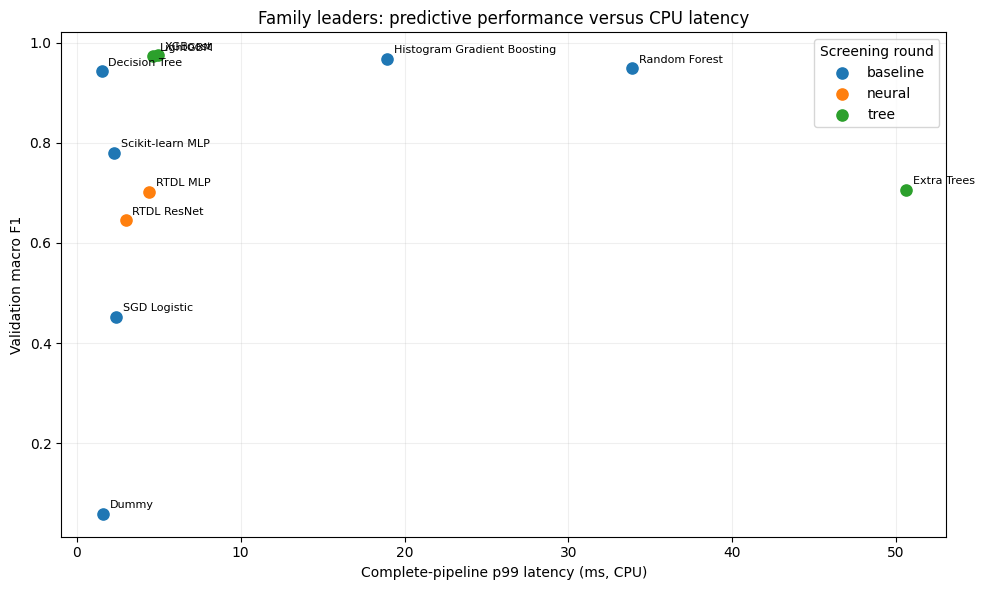

In [9]:
operational = family_summary.dropna(
    subset=["macro_f1", "latency_p99_ms"]
).copy()
lightgbm_operational_mask = operational["model"].eq("LightGBM")
for column in [
    "weighting_mode", "feature_set", "macro_f1",
    "training_time_seconds", "latency_p50_ms", "latency_p95_ms",
    "latency_p99_ms", "throughput_flows_per_second",
    "source_feature_count", "transformed_feature_count",
]:
    operational.loc[lightgbm_operational_mask, column] = lightgbm_selected[column]
operational.loc[lightgbm_operational_mask, "macro_f1_gap_to_leader"] = (
    lightgbm_selected["macro_f1"] - overall_leader_f1
)
operational.loc[lightgbm_operational_mask, "training_time_minutes"] = (
    lightgbm_selected["training_time_seconds"] / 60
)
frontier_rows = []
for candidate in operational.itertuples(index=False):
    dominated = (
        (operational["macro_f1"] >= candidate.macro_f1)
        & (operational["latency_p99_ms"] <= candidate.latency_p99_ms)
        & (
            (operational["macro_f1"] > candidate.macro_f1)
            | (operational["latency_p99_ms"] < candidate.latency_p99_ms)
        )
    ).any()
    if not dominated:
        frontier_rows.append(candidate)
frontier = pd.DataFrame(frontier_rows).sort_values("latency_p99_ms")
display(frontier[[
    "model", "macro_f1", "latency_p99_ms",
    "throughput_flows_per_second", "feature_set", "weighting_mode",
]].round({
    "macro_f1": 4,
    "latency_p99_ms": 3,
    "throughput_flows_per_second": 0,
}))

figure, axis = plt.subplots(figsize=(10, 6))
for round_name, rows in operational.groupby("screening_round"):
    axis.scatter(
        rows["latency_p99_ms"], rows["macro_f1"], s=65, label=round_name
    )
for row in operational.itertuples(index=False):
    axis.annotate(
        row.model,
        (row.latency_p99_ms, row.macro_f1),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )
axis.set_xlabel("Complete-pipeline p99 latency (ms, CPU)")
axis.set_ylabel("Validation macro F1")
axis.set_title("Family leaders: predictive performance versus CPU latency")
axis.legend(title="Screening round")
axis.grid(alpha=0.2)
figure.tight_layout()
plt.show()

## 10. Finalist feature-importance observations

The top model-reported features are shown for diagnostic inspection. XGBoost gain and LightGBM split-count importance are different quantities, so their numeric magnitudes must not be compared across models. Importance alone is not sufficient evidence for deleting a feature.

In [10]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    xgboost_importance = download_csv_artifact(
        xgboost_best["run_id"], "diagnostics/tree_feature_importance.csv"
    )
    lightgbm_importance = download_csv_artifact(
        lightgbm_selected["run_id"], "diagnostics/tree_feature_importance.csv"
    )

top_count = 10
xgboost_top = xgboost_importance.head(top_count).reset_index(drop=True)
lightgbm_top = lightgbm_importance.head(top_count).reset_index(drop=True)
importance_summary = pd.DataFrame({
    "rank": range(1, top_count + 1),
    "XGBoost feature": xgboost_top["feature"],
    "XGBoost importance": xgboost_top["importance"],
    "LightGBM feature": lightgbm_top["feature"],
    "LightGBM importance": lightgbm_top["importance"],
})
display(importance_summary)

shared_top_features = sorted(
    set(xgboost_top["feature"]) & set(lightgbm_top["feature"])
)
print(
    f"Shared top-{top_count} features ({len(shared_top_features)}): "
    + (", ".join(shared_top_features) if shared_top_features else "none")
)
print(
    f"LightGBM's highest-ranked feature is {lightgbm_top.iloc[0]['feature']}. "
    "Endpoint and port features require later generalization checks across time "
    "or environments; this observation is not an automatic removal decision."
)

,rank,XGBoost feature,XGBoost importance,LightGBM feature,LightGBM importance
0,1,Bwd Packet Length Max,0.125187,Src Port,12197
1,2,Bwd Packet Length Min,0.057805,Flow IAT Min,6503
2,3,Dst Port,0.051805,Fwd IAT Min,4593
3,4,Bwd Segment Size Avg,0.050420,FWD Init Win Bytes,4195
4,5,Fwd Packet Length Mean,0.041573,Dst Port,2696
5,6,Fwd Segment Size Avg,0.034574,Bwd Init Win Bytes,2210
6,7,Fwd Seg Size Min,0.033050,Fwd IAT Std,2165
7,8,Fwd Packet Length Min,0.031465,Fwd IAT Total,1988
8,9,Bwd Init Win Bytes,0.027856,Flow Duration,1963
9,10,PSH Flag Count,0.026230,Bwd Packets/s,1794


Shared top-10 features (2): Bwd Init Win Bytes, Dst Port
LightGBM's highest-ranked feature is Src Port. Endpoint and port features require later generalization checks across time or environments; this observation is not an automatic removal decision.


## 11. Findings and next decision

The conclusion follows the coverage, family ranking, paired feature/weighting checks, class-level errors, operational measurements, and importance diagnostics above.

In [11]:
histogram_rows = family_leaders.loc[
    family_leaders["model_family"].eq("HistGradientBoostingClassifier")
]
best_neural_family = family_leaders.loc[
    family_leaders["screening_round"].eq("neural")
].sort_values("macro_f1", ascending=False)
neural_missing = int(coverage.loc[
    coverage["screening_round"].eq("neural"),
    "missing_configurations",
].iloc[0])

training_reduction = (
    1
    - lightgbm_selected["training_time_seconds"]
    / xgboost_best["training_time_seconds"]
)
throughput_ratio = (
    xgboost_best["throughput_flows_per_second"]
    / lightgbm_selected["throughput_flows_per_second"]
)
lightgbm_mistake_reduction = (
    xgboost_counts["Total validation mistakes"]
    - lightgbm_counts["Total validation mistakes"]
)
lightgbm_false_alarm_reduction = (
    xgboost_counts["Benign rows predicted as attacks"]
    - lightgbm_counts["Benign rows predicted as attacks"]
)
lightgbm_p99_reduction = (
    1
    - lightgbm_selected["latency_p99_ms"]
    / xgboost_best["latency_p99_ms"]
)

findings = [
    "### Investigation conclusion",
    (
        f"**XGBoost is the screening leader** at macro F1 "
        f"**{xgboost_best['macro_f1']:.4f}** using "
        f"{xgboost_best['weighting_mode']} training and "
        f"{xgboost_best['feature_set']}. Its {macro_gap:.4f} advantage over "
        "LightGBM is mainly explained by the difficult web-attack classes."
    ),
    (
        f"**LightGBM with all 71 features remains a co-finalist** at macro F1 "
        f"**{lightgbm_selected['macro_f1']:.4f}**. It makes fewer total validation "
        f"mistakes and trains {training_reduction:.1%} faster; XGBoost "
        f"delivers about {throughput_ratio:.1f}x the measured batch throughput."
    ),
    (
        f"**The models lead on different objectives.** XGBoost is stronger on "
        f"macro F1 and the difficult XSS and Web Brute Force classes. LightGBM "
        f"shows the stronger operational profile: {lightgbm_mistake_reduction} "
        f"fewer total mistakes, {lightgbm_false_alarm_reduction} fewer benign "
        f"false alarms, identical attacks missed as benign, "
        f"{training_reduction:.1%} faster training, and "
        f"{lightgbm_p99_reduction:.1%} lower p99 CPU latency. Neither is a "
        "definitive winner after one split and seed."
    ),
    (
        f"**LightGBM ranks `{lightgbm_top.iloc[0]['feature']}` first by "
        "split-count importance.** Source ports are often temporary client-side "
        "values, so heavy use of them may capture the specific attacker tool, "
        "host, or attack session represented in CIC-IDS2017 rather than a pattern "
        "that transfers to another network. This is a generalization risk, not "
        "proof of leakage or a reason to remove the feature automatically; verify "
        "it with a paired port-ablation experiment after tuning."
    ),
    (
        "The reduced LightGBM schema is only 0.000089 higher in macro F1, "
        "whereas the full schema makes five fewer validation mistakes and four "
        "fewer benign false alarms. The full schema is therefore the more "
        "defensible tuning input; reduced_64 remains a post-tuning ablation."
    ),
]

if not histogram_rows.empty:
    histogram = histogram_rows.iloc[0]
    findings.append(
        f"**Histogram Gradient Boosting is the scikit-learn fallback** at macro "
        f"F1 **{histogram['macro_f1']:.4f}**, "
        f"{histogram['macro_f1'] - xgboost_best['macro_f1']:+.4f} behind XGBoost."
    )

if not best_neural_family.empty:
    neural = best_neural_family.iloc[0]
    findings.append(
        f"**Neural screening is not competitive at present.** The best completed "
        f"neural family, {display_model_name(neural['model_family'])}, reached "
        f"macro F1 **{neural['macro_f1']:.4f}** "
        f"({neural['macro_f1'] - xgboost_best['macro_f1']:+.4f} versus XGBoost). "
        f"The round still has {neural_missing} missing configurations, so this "
        "supports pausing it rather than claiming that every neural architecture failed."
    )

findings.extend([
    (
        "**Next step:** tune both XGBoost and LightGBM using all 71 eligible "
        "features, then verify the strongest settings across multiple seeds. "
        "LightGBM's reduced-64 screening advantage was only 0.000089 macro F1, "
        "which is too small to justify fixing that feature set before tuning."
    ),
    (
        "Use mean macro F1 across multiple seeds for the predictive decision. "
        "If one model's advantage is larger than the observed run-to-run "
        "variability, select that model. If their macro F1 is statistically "
        "indistinguishable, report a predictive tie and use false alarms, p99 "
        "latency, throughput, and complexity to choose the deployment candidate; "
        "the current operational evidence would favor LightGBM."
    ),
    (
        "After tuning, rerun each selected configuration with the reduced-64 "
        "schema as a final paired ablation. This separates hyperparameter "
        "selection from the decision about whether the seven manual removals "
        "provide a reproducible benefit."
    ),
    (
        "The protected test partition remains untouched. Final preprocessing, "
        "features, and hyperparameters must be locked before the one-time test "
        "evaluation."
    ),
])
display(Markdown("\n\n".join(findings)))

### Investigation conclusion

**XGBoost is the screening leader** at macro F1 **0.9745** using balanced training and all_71. Its 0.0021 advantage over LightGBM is mainly explained by the difficult web-attack classes.

**LightGBM with all 71 features remains a co-finalist** at macro F1 **0.9725**. It makes fewer total validation mistakes and trains 46.4% faster; XGBoost delivers about 3.6x the measured batch throughput.

**The models lead on different objectives.** XGBoost is stronger on macro F1 and the difficult XSS and Web Brute Force classes. LightGBM shows the stronger operational profile: 38 fewer total mistakes, 42 fewer benign false alarms, identical attacks missed as benign, 46.4% faster training, and 6.8% lower p99 CPU latency. Neither is a definitive winner after one split and seed.

**LightGBM ranks `Src Port` first by split-count importance.** Source ports are often temporary client-side values, so heavy use of them may capture the specific attacker tool, host, or attack session represented in CIC-IDS2017 rather than a pattern that transfers to another network. This is a generalization risk, not proof of leakage or a reason to remove the feature automatically; verify it with a paired port-ablation experiment after tuning.

The reduced LightGBM schema is only 0.000089 higher in macro F1, whereas the full schema makes five fewer validation mistakes and four fewer benign false alarms. The full schema is therefore the more defensible tuning input; reduced_64 remains a post-tuning ablation.

**Histogram Gradient Boosting is the scikit-learn fallback** at macro F1 **0.9670**, -0.0075 behind XGBoost.

**Neural screening is not competitive at present.** The best completed neural family, RTDL MLP, reached macro F1 **0.7019** (-0.2726 versus XGBoost). The round still has 8 missing configurations, so this supports pausing it rather than claiming that every neural architecture failed.

**Next step:** tune both XGBoost and LightGBM using all 71 eligible features, then verify the strongest settings across multiple seeds. LightGBM's reduced-64 screening advantage was only 0.000089 macro F1, which is too small to justify fixing that feature set before tuning.

Use mean macro F1 across multiple seeds for the predictive decision. If one model's advantage is larger than the observed run-to-run variability, select that model. If their macro F1 is statistically indistinguishable, report a predictive tie and use false alarms, p99 latency, throughput, and complexity to choose the deployment candidate; the current operational evidence would favor LightGBM.

After tuning, rerun each selected configuration with the reduced-64 schema as a final paired ablation. This separates hyperparameter selection from the decision about whether the seven manual removals provide a reproducible benefit.

The protected test partition remains untouched. Final preprocessing, features, and hyperparameters must be locked before the one-time test evaluation.